In [3]:
import matplotlib.pyplot as plt  # Plotten im Notebook
import subprocess
import sys

def run_on_pico(code: str, port: str = "COM3", exec_timeout_s: float = 40.0):
    cmd = [sys.executable, "-m", "mpremote", "connect", port, "exec", code]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=exec_timeout_s)
    return proc.stdout.strip(), proc.stderr.strip()

cmd = [sys.executable, "-m", "mpremote", "connect", "list"]
ports = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
print(ports.stdout.strip() or "Keine Ports von mpremote erkannt.")
if ports.stderr.strip():
    print("stderr:\n", ports.stderr.strip())

COM3 E6605481DB6BBA37 2e8a:0005 Microsoft None


In [1]:
code = f'''
from machine import ADC

sensor = ADC(4)
raw = sensor.read_u16()
voltage = raw * 3.3 / 65535
temp_c = 27 - (voltage - 0.706) / 0.001721
print(f"{{temp_c:.2f}}")
'''

In [4]:

for i in range(10):
    temp, err = run_on_pico(code)
    print(temp)

26.58
25.17
24.70
25.17
24.70
25.17
25.17
25.17
25.17
24.70


In [4]:
import pandas as pd

daten = []
aktuelle_zeit = 0
for i in range(10):
    temp, err = run_on_pico(code)
    print(temp)
    aktuelle_zeit = aktuelle_zeit + 0.5
    
    daten.append([aktuelle_zeit, temp])

df = pd.DataFrame(daten, columns=["Zeit (s)", "Temperatur"])
print(df)

25.17
23.30
22.83
22.83
22.36
22.83
22.36
22.36
22.83
22.83
   Zeit (s) Temperatur
0       0.5      25.17
1       1.0      23.30
2       1.5      22.83
3       2.0      22.83
4       2.5      22.36
5       3.0      22.83
6       3.5      22.36
7       4.0      22.36
8       4.5      22.83
9       5.0      22.83


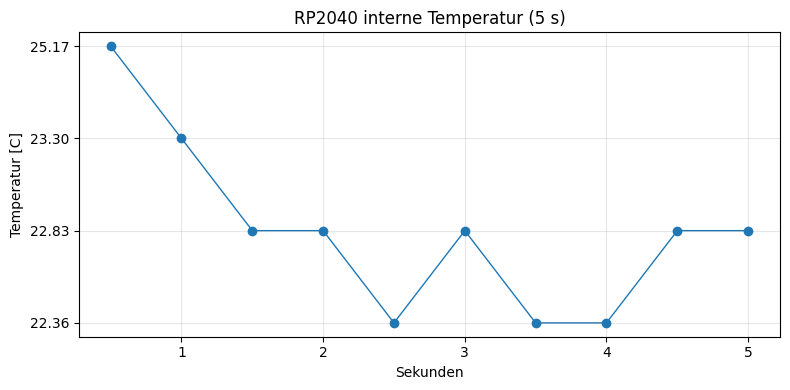

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df["Zeit (s)"], df["Temperatur"], marker='o', linewidth=1)
plt.xlabel('Sekunden')
plt.ylabel('Temperatur [C]')
plt.title(f'RP2040 interne Temperatur (5 s)')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Mein Plot'}>

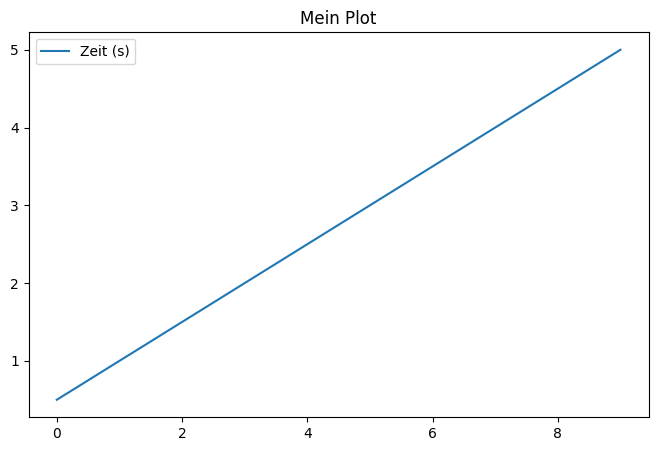

In [59]:
df.plot(title="Mein Plot", figsize=(8,5))